# Dependencies

In [1]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(ggbeeswarm)
})

source("./utils.R")

In [2]:
limits_ari <- c(-0.05, 1)

# Fig1D

In [3]:
ari_tech <- read_tsv("./data/ari.tsv", show_col_types = FALSE, col_select = 2:5)

head(ari_tech)

New names:
• `` -> `...1`


Method,Data,Technology,ARI
<chr>,<chr>,<chr>,<dbl>
BANKSY,STARmap_plus,STARmap+,0.5865460
BANKSY,abc_atlas_wmb_thalamus,MERFISH,0.4276500
BANKSY,cosmx_liver,cosmx,0.1910292
BANKSY,cosmx_lung,cosmx,0.2429630
BANKSY,libd_dlpfc,Visium,0.3923225
BANKSY,merfish_devheart,Merfish,0.5797235


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


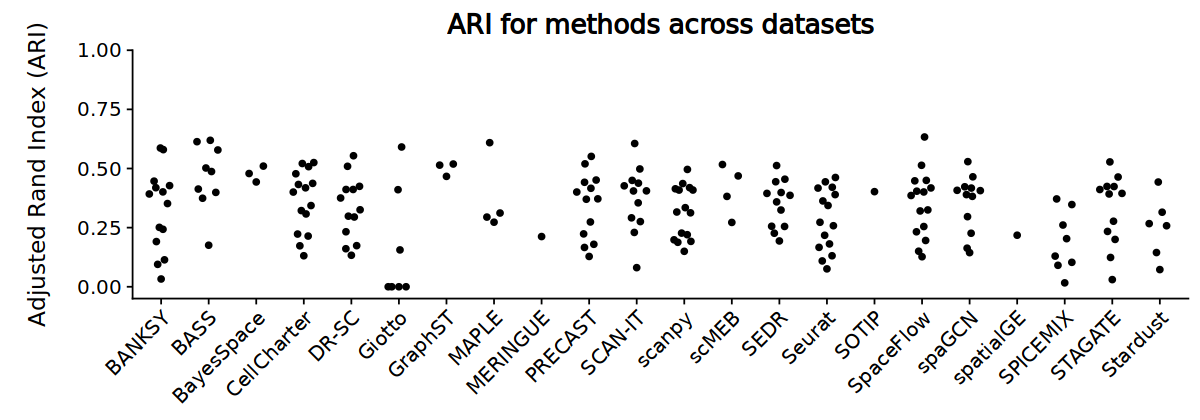

In [4]:
options(repr.plot.width = 10, repr.plot.height = 3.5)

fig_1D <- ari_tech |>
    ggplot(aes(x = Method, y = ARI)) +
    geom_quasirandom(width = 0.3) +
    scale_y_continuous("Adjusted Rand Index (ARI)", limits = limits_ari, expand = c(0, 0)) +
    labs(x = NULL, title = "ARI for methods across datasets") +
    theme_pub() +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
        axis.title.y = element_text(margin = margin(r = 15, l = 10, unit = "pt"))
    )

fig_1D

## Figure E

In [5]:
# Load results
ari_conf <- read_tsv("./data/SpaceHack_ARI_libd.tsv", show_col_types = FALSE) %>%
    group_by(Method, Config) %>%
    filter(n() > 1) |>
    ungroup()

In [6]:
# relabel configs
ari_conf <- filter(ari_conf, Config != "config_default") %>%
    group_by(Method) %>%
    mutate(Config = paste0("config", dense_rank(forcats::fct_reorder(Config, ARI, .fun = mean, .desc = TRUE)))) %>%
    bind_rows(
        filter(ari_conf, Config == "config_default") %>%
            mutate(Config = "default")
    )

In [7]:
method_order <- ari_conf |>
    group_by(Method) |>
    summarize(ARI = mean(ARI)) |>
    arrange(-ARI) |>
    pull(Method)

n_conf <- length(unique(ari_conf$Config))

config_order <- c("default", paste0("config", 1:(n_conf - 1)))

ari_conf <- mutate(ari_conf,
    Method = factor(Method, levels = method_order),
    Config = factor(Config, levels = config_order)
)

In [8]:
wes_palette <- c(
    "#FD6467", "#0B775E", # "#2F343B",
    "#87B2C7", "#9B5094", "#F1BB7B", "#3E442B",
    "#F98400", "#09ACEC", "#FFDE05", "#DF9D5A", "#F2D3BC", "#DAD6D6"
)

wes_dic <- wes_palette[1:n_conf] %>%
    set_names(config_order)

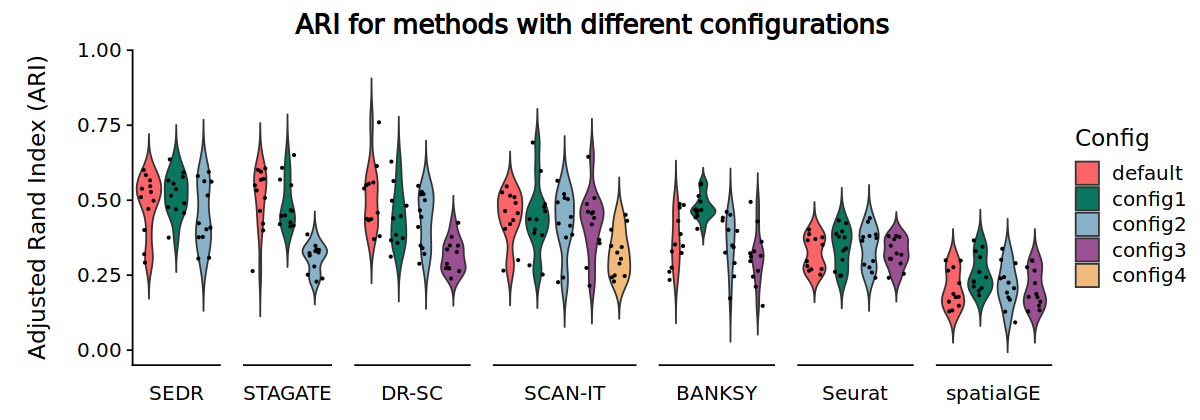

In [9]:
options(repr.plot.width = 10, repr.plot.height = 3.5)

fig_1E <- ari_conf |>
    group_by(Method) |>
    mutate(n_config = n_distinct(Config)) |>
    ungroup() |>
    filter(n_config >= 4 | Method %in% c("STAGATE", "SEDR"), Method != "SOTIP") |>
    ggplot(aes(x = Config, y = ARI, fill = Config)) +
    facet_grid(~Method, space = "free_x", scales = "free_x", switch = "x") +
    geom_violin(trim = FALSE, bounds = c(-0.5, 1)) +
    geom_jitter(color = "black", fill = "black", size = 0.5, width = 0.3) +
    scale_fill_manual(values = wes_dic) +
    scale_y_continuous("Adjusted Rand Index (ARI)", limits = limits_ari, expand = c(0, 0)) +
    labs(x = NULL, title = "ARI for methods with different configurations", fill = "Config") +
    theme_pub() +
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        strip.placement = "outside",
        strip.background = element_blank(),
        panel.spacing = unit(1, "lines"),
        axis.title.y = element_text(margin = margin(r = 15, l = 10, unit = "pt"))
    )

fig_1E

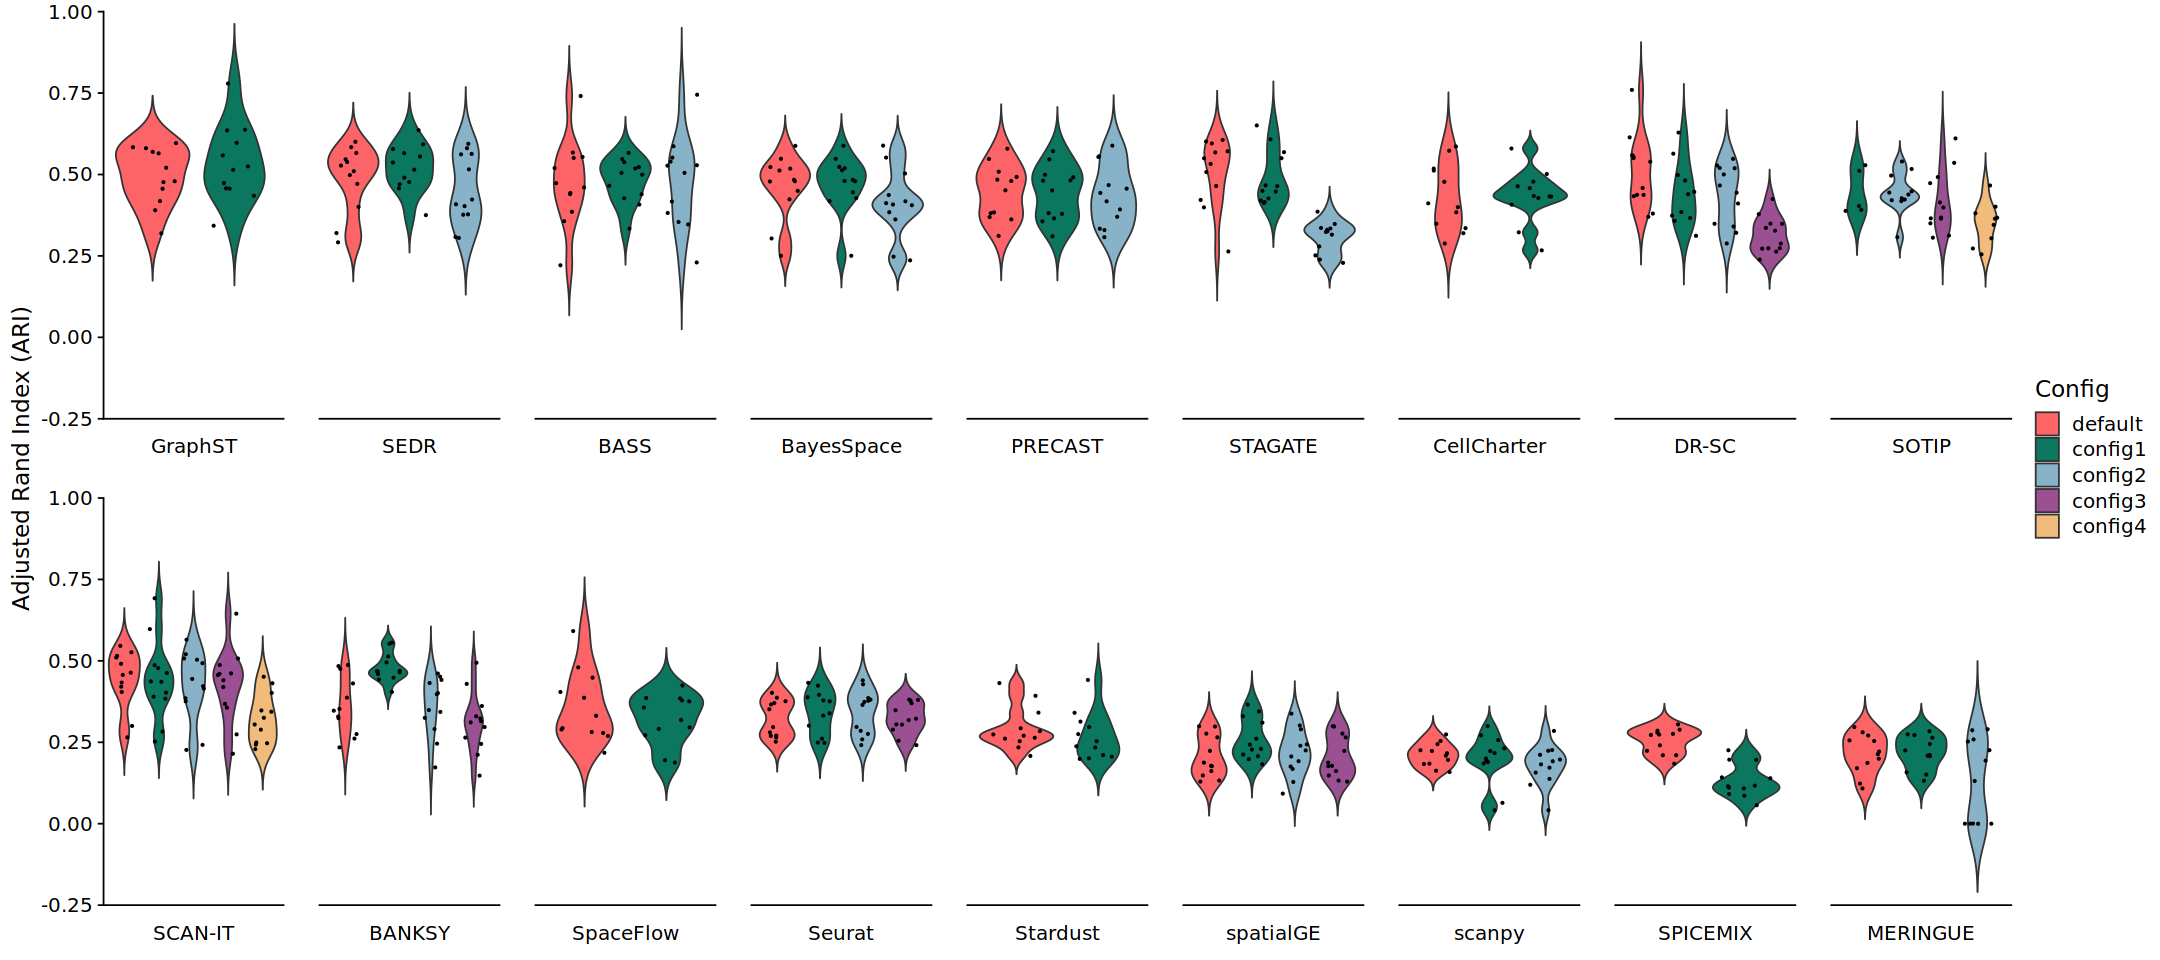

In [10]:
options(repr.plot.width = 18, repr.plot.height = 8)

fig_1E_supp <- ari_conf |>
    group_by(Method) |>
    filter(n_distinct(Config) >= 2) |>
    ggplot(aes(x = Config, y = ARI, fill = Config)) +
    facet_wrap(~Method, scales = "free_x", strip.position = "bottom", ncol = 9) +
    geom_violin(trim = FALSE, bounds = c(-0.5, 1)) +
    geom_jitter(color = "black", fill = "black", size = 0.5, width = 0.3) +
    scale_fill_manual(values = wes_dic) +
    scale_y_continuous("Adjusted Rand Index (ARI)", limits = c(-0.25, 1), expand = c(0, 0)) +
    labs(x = NULL, fill = "Config") +
    theme_pub() +
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        strip.placement = "outside",
        strip.background = element_blank(),
        panel.spacing = unit(1.5, "lines"),
        # axis.title.y = element_text(margin = margin(r = 10, l = 10, unit = "pt"))
    )

fig_1E_supp |>
    ggsave(filename = "Fig1E_supplemental.pdf", height = unit(7, "inches"), width = unit(18, "inches"))

fig_1E_supp

# Composition

In [11]:
library(cowplot)

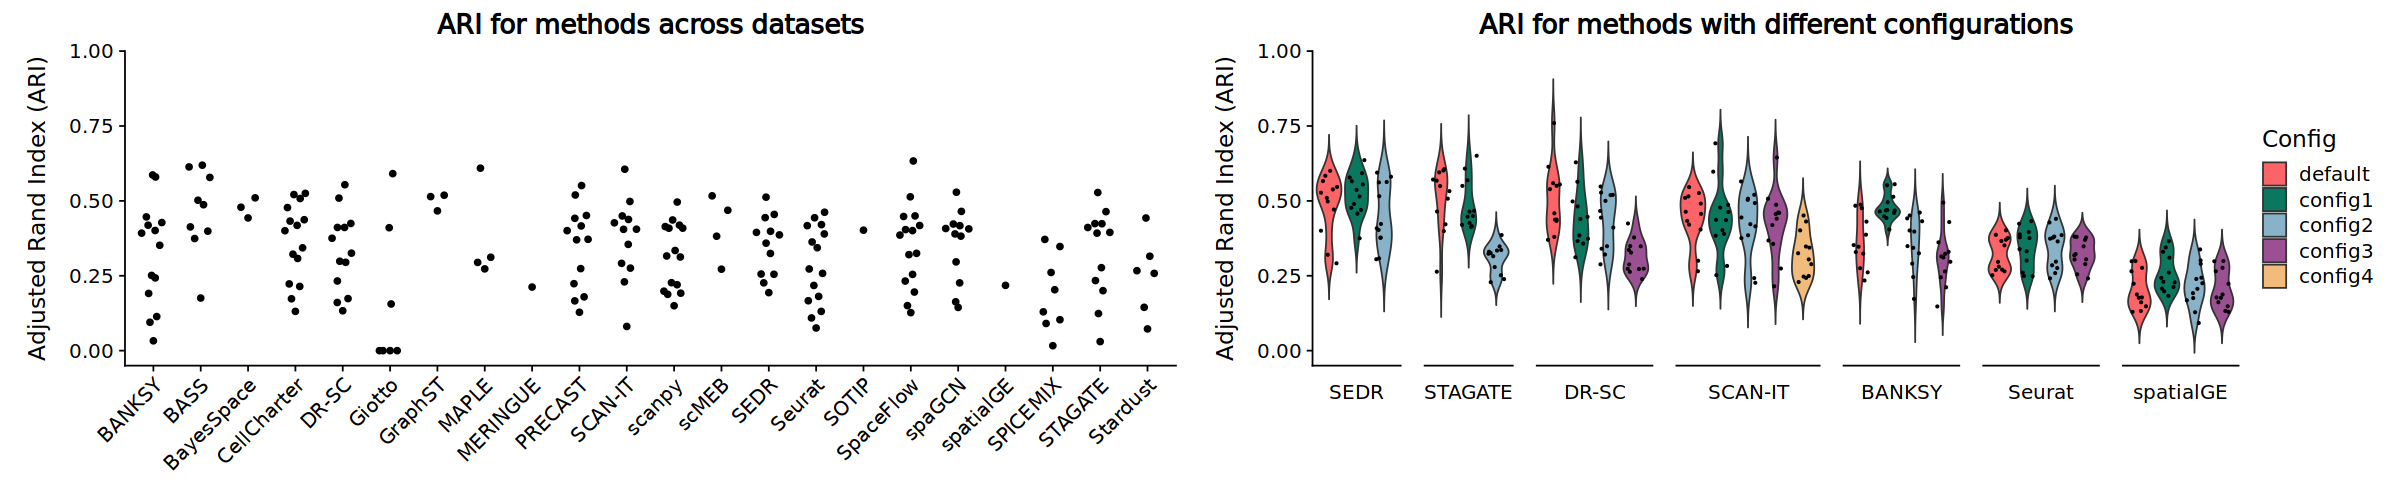

In [12]:
options(repr.plot.width = 20, repr.plot.height = 4)

fig_1ED <- plot_grid(fig_1D, fig_1E, align = "h", axis = "tb", nrow = 1) +
    theme(plot.margin = margin(r = 15, unit = "pt"))

fig_1ED |>
    ggsave(
        filename = "Fig1ED.pdf",
        height = unit(4, "inches"),
        width = unit(20, "inches")
    )

fig_1ED

In [13]:
fig_1ED |>
    ggsave(
        filename = "Fig1ED.png",
        height = unit(4, "inches"),
        width = unit(20, "inches")
    )